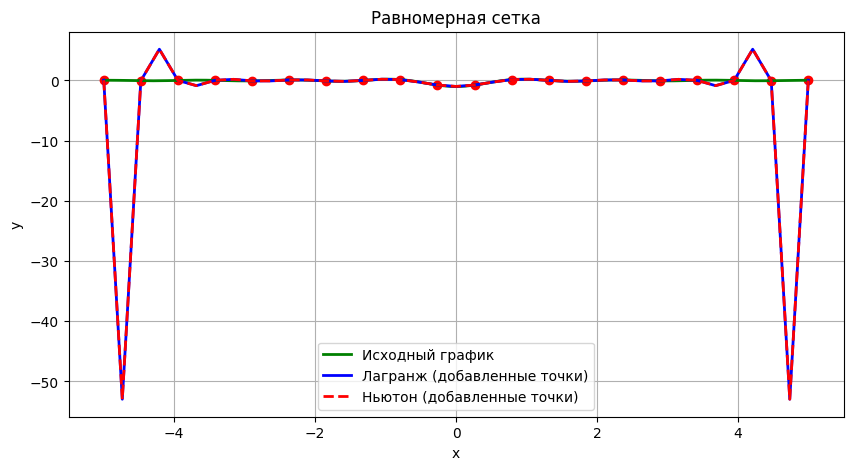

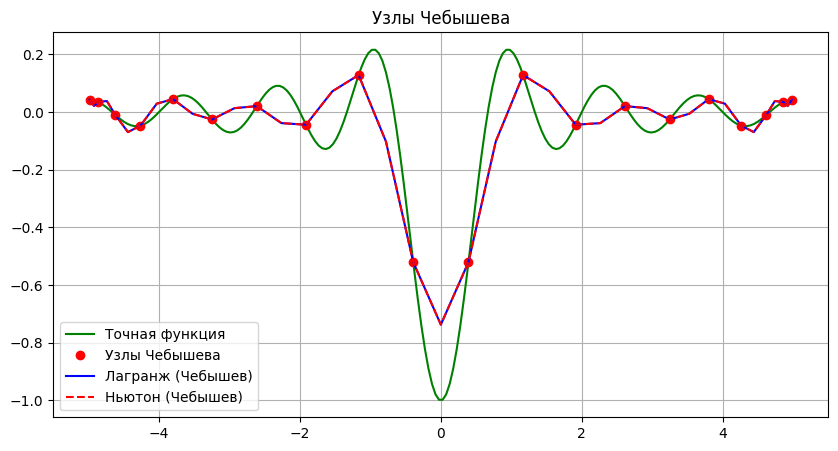

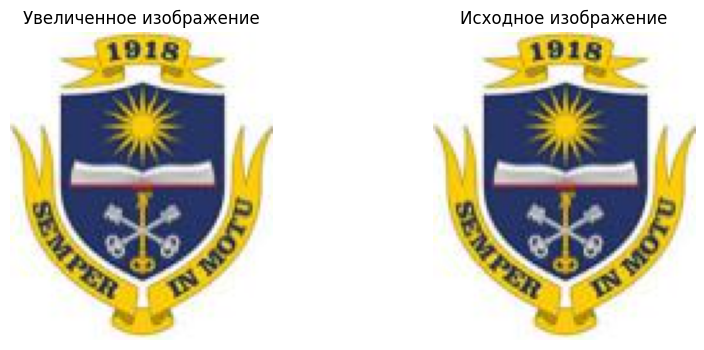

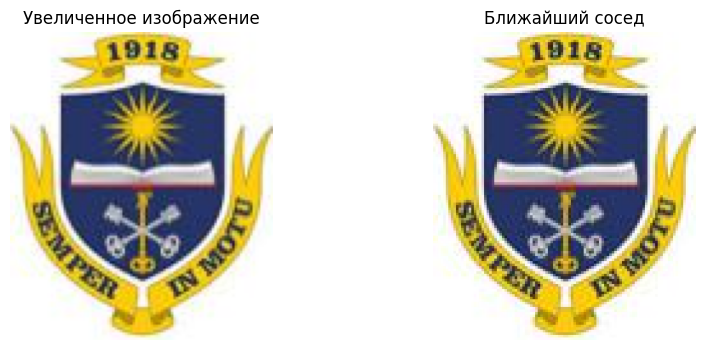

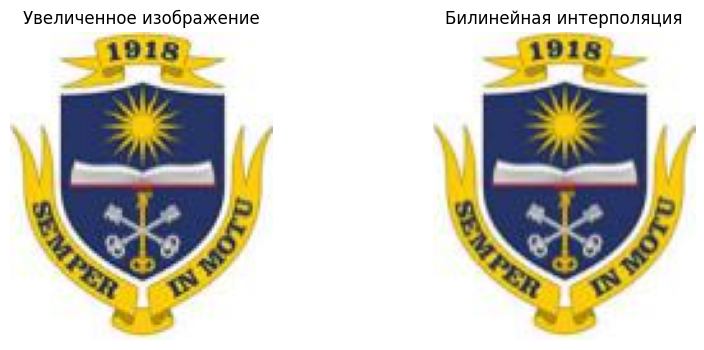

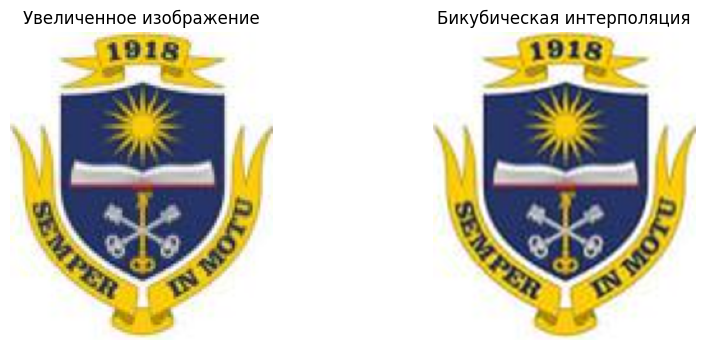

In [1]:
import numpy as np
from scipy.ndimage import zoom as scipy_zoom
import matplotlib.pyplot as plt

data = np.genfromtxt('Task_Data_Interpolation.csv', delimiter=';', skip_header=1)

x = data[:, 0]  
y = data[:, 1]

def f_exact(x):
    return -np.sinc(1.5 * x)  

x_origen = np.linspace(-5, 5, 200)
y_origen = f_exact(x_origen)

def lagrange(x, x_nodes, y_nodes):
    n = len(x_nodes)
    result = 0
    for i in range(n):
        term = y_nodes[i]
        for j in range(n):
            if j != i:
                term *= (x - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        result += term
    return result
        
def newton(x, x_nodes, y_nodes):
    n = len(x_nodes)
    # таблица разделённых разностей
    div_diff = np.zeros((n, n))
    div_diff[:, 0] = y_nodes
    for j in range(1, n):
        for i in range(n - j):
            div_diff[i, j] = (div_diff[i+1, j-1] - div_diff[i, j-1]) / (x_nodes[i+j] - x_nodes[i])
    
    # вычисление значения
    result = div_diff[0, 0]
    term = 1
    for i in range(1, n):
        term *= (x - x_nodes[i-1])
        result += div_diff[0, i] * term
    return result


#равномерная сетка

x_new = np.sort(np.unique(np.concatenate([x, (x[:-1] + x[1:]) / 2])))

y_lagrang = []
for xi in x_new:
    yi = lagrange(xi, x, y)
    y_lagrang.append(yi)

y_newton = []
for xi in x_new:
    yi = newton(xi, x, y)
    y_newton.append(yi)


plt.figure(figsize=(10, 5))
plt.plot(x,y, 'ro')
plt.plot(x_origen, y_origen, color='green', label='Исходный график', lw=2)
plt.plot(x_new, y_lagrang, color='blue', label='Лагранж (добавленные точки)', lw=2)
plt.plot(x_new, y_newton,'--', color='red', label='Ньютон (добавленные точки)', lw=2)
plt.title('Равномерная сетка')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend()


#по Чебышеву
n_cheb = 20
a, b = -5, 5
X_c = [(a+b)/2 + (b-a)/2 * np.cos((2*k - 1)* np.pi/(2*n_cheb)) for k in range(1, n_cheb+1)]
x_cheb = np.array(sorted(X_c))
y_cheb = f_exact(x_cheb)

x_cheb_new = np.sort(np.unique(np.concatenate([x_cheb, (x_cheb[:-1] + x_cheb[1:]) / 2])))

y_cheb_lagrange = []
for xi in x_cheb_new:   
    yi = lagrange(xi, x_cheb, y_cheb)
    y_cheb_lagrange.append(yi)

y_cheb_newton = []
for xi in x_cheb_new:
    yi = newton(xi, x_cheb, y_cheb)
    y_cheb_newton.append(yi)

plt.figure(figsize=(10, 5))
plt.plot(x_origen, y_origen, color='green', label='Точная функция')
plt.plot(x_cheb, y_cheb, 'ro', label='Узлы Чебышева')
plt.plot(x_cheb_new, y_cheb_lagrange, color='blue', label='Лагранж (Чебышев)')
plt.plot(x_cheb_new, y_cheb_newton, '--', color='red',  label='Ньютон (Чебышев)')
plt.legend()
plt.title('Узлы Чебышева')
plt.grid()


# изображение
img = plt.imread('task_vsu_gerb.jpeg')
factor = 2

def zoom_nearest(img, factor):
    """Интерполяция по ближайшим соседям"""
    h, w = img.shape[:2]
    new_img = np.repeat(np.repeat(img, factor, axis=0), factor, axis=1)
    return new_img

def zoom_linear_manual(img, factor):
    """Билинейная интерполяция"""
    h, w = img.shape[:2]
    new_h, new_w = int(h*factor), int(w*factor)
    new_img = np.zeros((new_h, new_w, img.shape[2]), dtype=img.dtype)
    
    for i in range(new_h):
        for j in range(new_w):
            # Координаты в исходном изображении
            orig_i = i / factor
            orig_j = j / factor
            
            # Четыре ближайших пикселя
            i1 = int(np.floor(orig_i))
            i2 = min(i1 + 1, h - 1)
            j1 = int(np.floor(orig_j))
            j2 = min(j1 + 1, w - 1)
            
            # Веса
            di = orig_i - i1
            dj = orig_j - j1
            
            for c in range(img.shape[2]):
                # Билинейная интерполяция
                val = (1-di)*(1-dj) * img[i1, j1, c] + \
                      (1-di)*dj     * img[i1, j2, c] + \
                      di*(1-dj)     * img[i2, j1, c] + \
                      di*dj         * img[i2, j2, c]
                new_img[i, j, c] = val
    return new_img

def zoom_bicubic(img, factor):
    new_img = scipy_zoom(img, (factor, factor, 1), order=3)
    return new_img

img_nearest = zoom_nearest(img, factor)
img_linear = zoom_linear_manual(img, factor)
img_bicubic = zoom_bicubic(img, factor)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 2)
plt.imshow(img) #Показывает изображение в виде картинки
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 1)
plt.imshow(img, extent=[0, img.shape[1]*2, 0, img.shape[0]*2]) #Показывает изображение в виде картинки
plt.title('Увеличенное изображение')
plt.axis('off')

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 2)
plt.imshow(img_nearest)
plt.title('Ближайший сосед')
plt.axis('off')

plt.subplot(1, 2, 1)
plt.imshow(img, extent=[0, img.shape[1]*2, 0, img.shape[0]*2]) #Показывает изображение в виде картинки
plt.title('Увеличенное изображение')
plt.axis('off')

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 2)
plt.imshow(img_linear)
plt.title('Билинейная интерполяция')
plt.axis('off')

plt.subplot(1, 2, 1)
plt.imshow(img, extent=[0, img.shape[1]*2, 0, img.shape[0]*2]) #Показывает изображение в виде картинки
plt.title('Увеличенное изображение')
plt.axis('off')

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 2)
plt.imshow(img_bicubic)
plt.title('Бикубическая интерполяция')
plt.axis('off')

plt.subplot(1, 2, 1)
plt.imshow(img, extent=[0, img.shape[1]*5, 0, img.shape[0]*5]) #Показывает изображение в виде картинки
plt.title('Увеличенное изображение')
plt.axis('off')


plt.show()